### Data Collection

In [8]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

In [18]:
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data["Species"] = iris.target

data["Species"] = data["Species"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

In [19]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Data Understanding

In [20]:
data.shape

(150, 5)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Exploratory Data Analysis

In [23]:
import plotly.express as px

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [31]:
### Scatter plot
fig = px.scatter(
    data,
    x="sepal length (cm)",
    y="sepal width (cm)",
    color="Species",
    title= "Sepal Length vs Sepal Width"

)

fig.show()

In [32]:
### Scatter plot Matrix
fig = px.scatter_matrix(
    data,
    dimensions = iris.feature_names,
    color="Species",
    title="Scatter Matrix Plot"
)

fig.show()

In [33]:
### Scatter plot 3d
fig = px.scatter_3d(
    data,
    x = "sepal length (cm)",
    y = "sepal width (cm)",
    z = "petal length (cm)",
    color = "Species",
    title = "3D Scatter Plot"
)

fig.show()

### Data Preparation

#### Dataset for iris is quite clean allready. Hence there is no Data preparation/preprocessing

### Data Modelling

In [39]:
### Differentiate between x = independent variables ,  y = dependent variable

X = data.drop(columns = "Species",axis=1)
y = data["Species"]

In [43]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size = 0.2, random_state = 42)

In [53]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [55]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


DecisionTreeClassifier()

In [60]:
y_pred = dt.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

In [63]:
print("Decision Tree Base Model Accuracy",
      accuracy_score(y_test, y_pred))

Decision Tree Base Model Accuracy 1.0


### Shallow Decision Tree

In [ ]:
## Parameter max_depth = 2

In [64]:
dt_shallow = DecisionTreeClassifier(max_depth=2)

In [65]:
dt_shallow.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

In [67]:
y_pred_shallow = dt_shallow.predict(X_test)

In [68]:
print("Decision Tree Shallow Model Accuracy",
      accuracy_score(y_test, y_pred_shallow))

Decision Tree Shallow Model Accuracy 0.9666666666666667


In [75]:
results = pd.DataFrame({
    "Model": ["Base Model", "Shallow Model"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_shallow)
    ]
})

print(results)

           Model  Accuracy
0     Base Model  1.000000
1  Shallow Model  0.966667


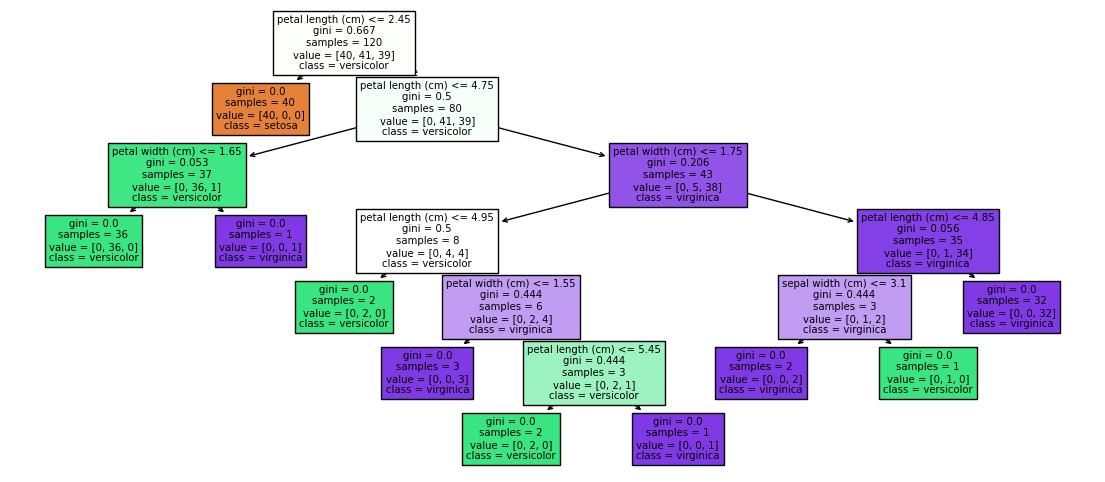

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plot_tree(dt,
          feature_names= iris.feature_names,
          class_names=iris.target_names,
          filled=True

)

plt.show()

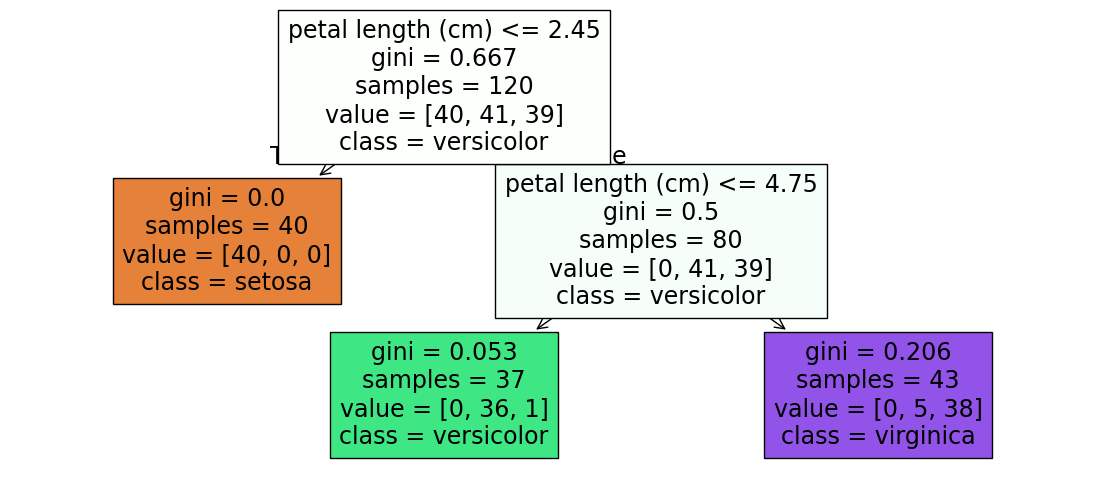

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plot_tree(dt_shallow,
          feature_names= iris.feature_names,
          class_names=iris.target_names,
          filled=True

)

plt.show()